In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import json 
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter 
from scipy.signal import find_peaks
from Oscilloscope.Oscilloscope import Oscilloscope

**burada işimizi kolaylaştırmak Oscilloscope adında bir class oluşturdum**

In [2]:
osiloskop_info = Oscilloscope(['detektor data 2/P10/Kare/Kare 10x10/6x6/p10 8000V kaynaksız/2.bin','detektor data 2/P10/Kare/Kare 10x10/6x6/p10 8000V kaynaksız/3.bin'])
osiloskop_info.channel[1].data

[-4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.12,
 -4.12,
 -4.12,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.2,
 -4.2,
 -4.2,
 -4.2,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.28,
 -4.28,
 -4.28,
 -4.32,
 -4.32,
 -4.32,
 -4.32,
 -4.32,
 -4.32,
 -4.36,
 -4.36,
 -4.32,
 -4.32,
 -4.36,
 -4.4,
 -4.4,
 -4.4,
 -4.4,
 -4.36,
 -4.36,
 -4.36,
 -4.36,
 -4.4,
 -4.44,
 -4.44,
 -4.44,
 -4.48,
 -4.48,
 -4.48,
 -4.48,
 -4.4,
 -4.4,
 -4.44,
 -4.44,
 -4.48,
 -4.4,
 -4.4,
 -4.4,
 -4.36,
 -4.36,
 -4.36,
 -4.36,
 -4.4,
 -4.36,
 -4.32,
 -4.36,
 -4.32,
 -4.32,
 -4.32,
 -4.28,
 -4.24,
 -4.28,
 -4.24,
 -4.2,
 -4.2,
 -4.2,
 -4.2,
 -4.24,
 -4.24,
 -4.2,
 -4.2,
 -4.2,
 -4.2,
 -4.2,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.16,
 -4.12,
 -4.12,
 -4.16,
 -4.16,
 -4.16,
 -4.2,
 -4.16,
 -4.12,
 -4.16,
 -4.08,
 -4.12,
 -4.2,
 -4.2,
 -4.24,
 -4.24,
 -4.2,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.24,
 -4.28,
 -4.28,
 -4.28,
 -4.28,
 -4.32,
 -4.32,
 -4.

In [3]:
#osiloskop_info.saveAsJson('berker/data.json')

In [4]:
readData = pd.DataFrame(osiloskop_info.channel[1].data)

In [5]:
readData[readData[0]>0.25]

,0
513,5.08
514,5.08
515,0.56
1273,5.08
1274,2.68
1372,5.08
1373,1.92


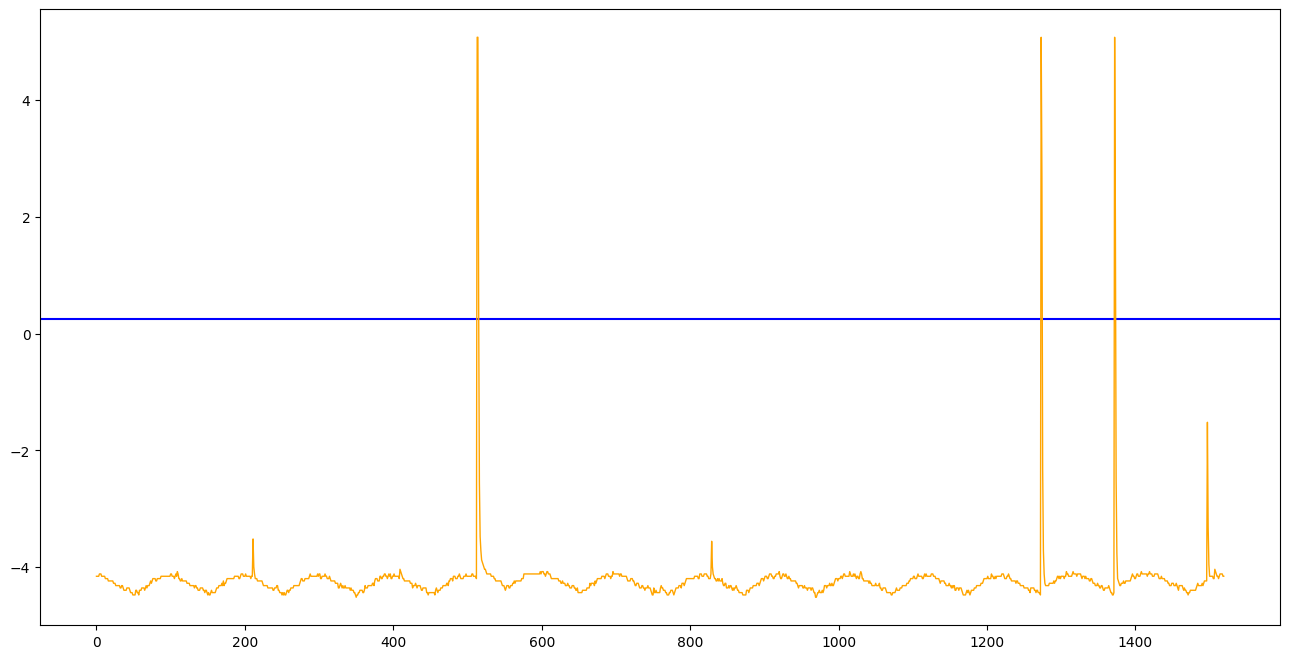

In [6]:
plt.figure(figsize=(16, 8))
plt.axhline(0.25, color = 'blue', linestyle = '-')
plt.plot(readData, color="orange", linewidth=1)

In [7]:
smootedData = readData[[0]].apply(savgol_filter,  window_length=4, polyorder=3)
smootedData2 = smootedData[[0]].apply(savgol_filter,  window_length=5, polyorder=3)

array([[<Axes: title={'center': '0'}>]], dtype=object)

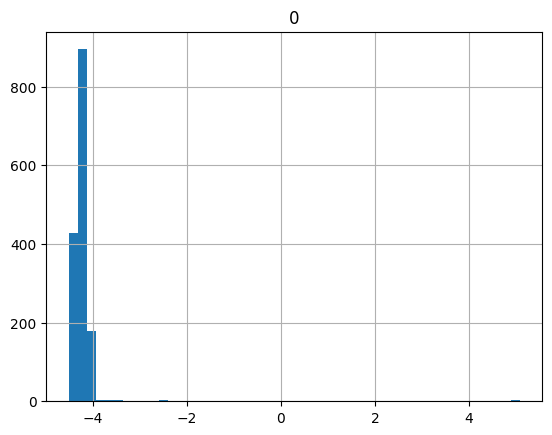

In [8]:
readData.hist(bins=50)

In [9]:
np.histogram(readData[[0]],bins = 50)

(array([427, 895, 178,   3,   3,   2,   1,   0,   0,   0,   2,   1,   0,
          0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          1,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   1,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4]),
 array([-4.52 , -4.328, -4.136, -3.944, -3.752, -3.56 , -3.368, -3.176,
        -2.984, -2.792, -2.6  , -2.408, -2.216, -2.024, -1.832, -1.64 ,
        -1.448, -1.256, -1.064, -0.872, -0.68 , -0.488, -0.296, -0.104,
         0.088,  0.28 ,  0.472,  0.664,  0.856,  1.048,  1.24 ,  1.432,
         1.624,  1.816,  2.008,  2.2  ,  2.392,  2.584,  2.776,  2.968,
         3.16 ,  3.352,  3.544,  3.736,  3.928,  4.12 ,  4.312,  4.504,
         4.696,  4.888,  5.08 ]))

In [10]:
sorted = readData.sort_values(0)
filtered = sorted[int(len(sorted)*0.2):int(len(sorted)*0.80)]
filtered

,0
63,-4.36
444,-4.36
443,-4.36
442,-4.36
68,-4.36
...,...
88,-4.16
87,-4.16
11,-4.16
10,-4.16


In [11]:
mode = readData.mode()
mode

,0
0,-4.16


In [12]:
std = np.std(filtered[0])
std

0.06715145755506564

In [13]:
avg = np.average(filtered[0])
avg

-4.257456140350878

In [14]:
trshld = avg + std*(2+2**0.5)
peaks, _ = find_peaks(smootedData[0],threshold = 0.04)
filtredPeaks = smootedData[0][peaks][smootedData[0]>0]
filtredPeaks = filtredPeaks.keys()

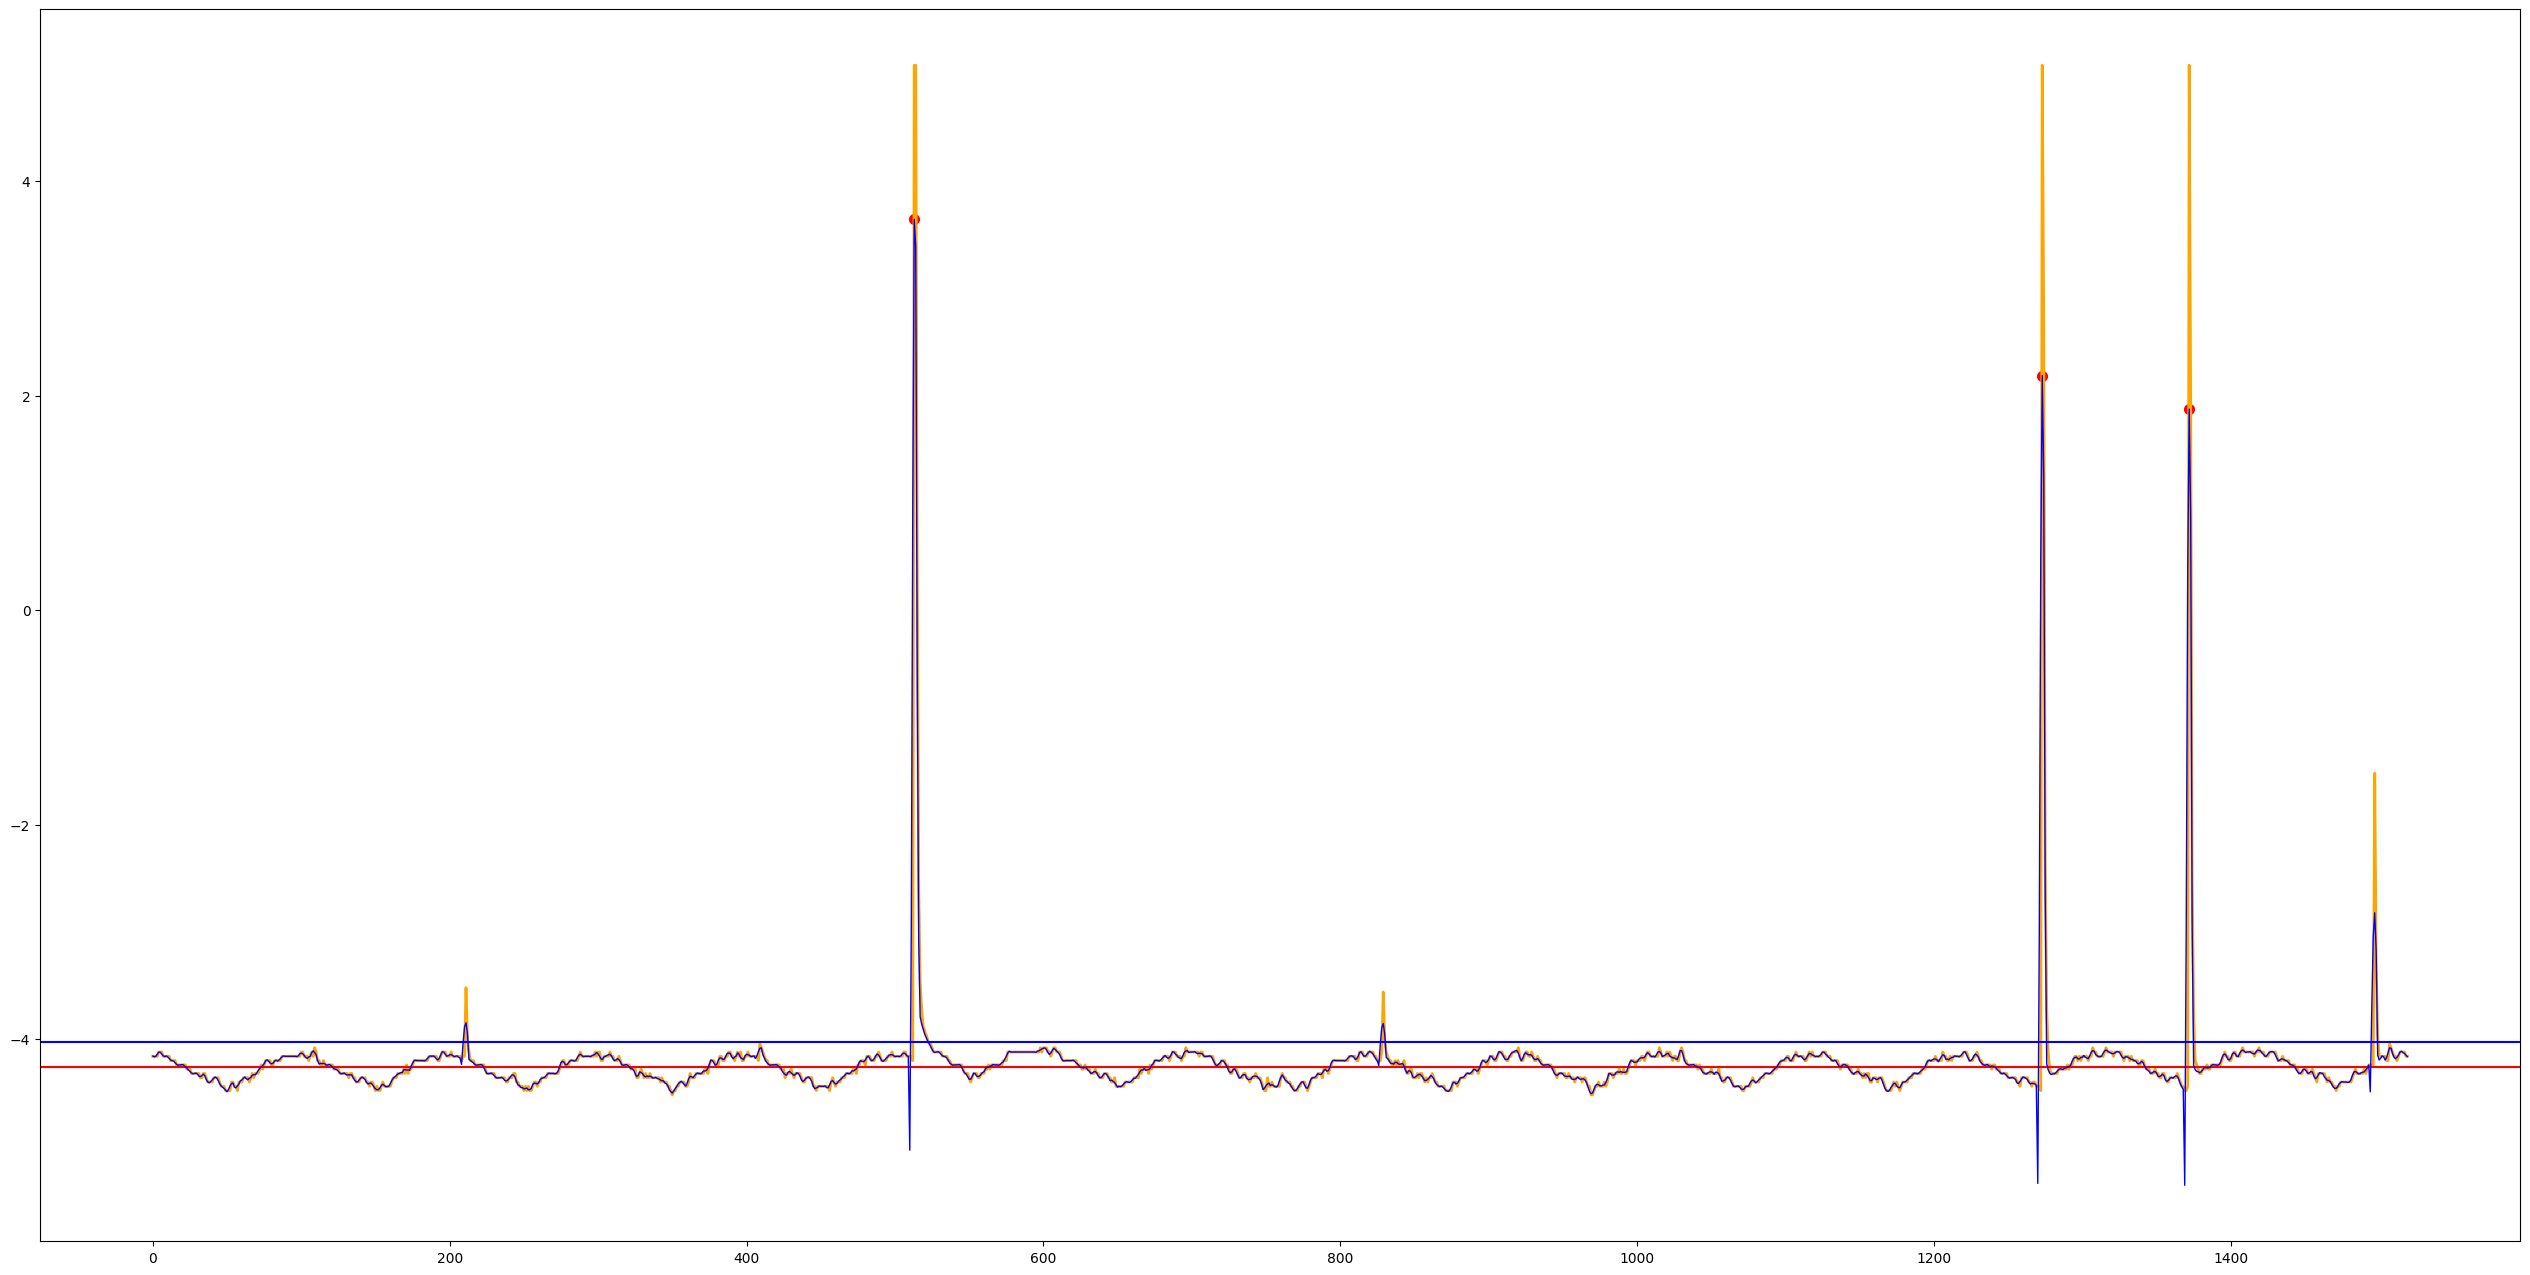

In [15]:

plt.figure(figsize=(32, 16))
plt.plot(range(0,len(readData)),readData, color="orange", linewidth=2)

plt.axhline(avg, color = 'r', linestyle = '-')
plt.axhline(trshld, color = 'blue', linestyle = '-')

plt.plot(range(0,len(smootedData)),smootedData, color="blue", linewidth=1)
##plt.plot(range(0,len(smootedData2)),smootedData2, color="purple", linewidth=1)
plt.scatter(filtredPeaks,smootedData[0][filtredPeaks], color="red", linewidth=2)

plt.show()

In [16]:
readData[readData[0]> trshld] 

,0
211,-3.52
212,-4.00
513,5.08
514,5.08
515,0.56
516,-2.56
517,-3.48
518,-3.72
519,-3.88
520,-3.92
